In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### DATA UNDERSTANDING

In [2]:
df = pd.read_csv('insurance.csv')
print(df.head())

df.info()

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


# DATA CLEANING

## Cek Missing Value

In [3]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


## Cek Duplikat

In [4]:
if df.duplicated().any():
  print("Terdapat Data Duplikat")
  print(df[df.duplicated(keep=False)])
  print("\nJumlah Data Duplikat:", df.duplicated().sum())

  df.drop_duplicates(keep='first', inplace=True)
  print("\nJumlah Data Duplikat : ", df.duplicated().sum())
else:
  print("There is no duplicate")



Terdapat Data Duplikat
     age   sex    bmi  children smoker     region    charges
195   19  male  30.59         0     no  northwest  1639.5631
581   19  male  30.59         0     no  northwest  1639.5631

Jumlah Data Duplikat: 1

Jumlah Data Duplikat :  0


## Outlier Analysis

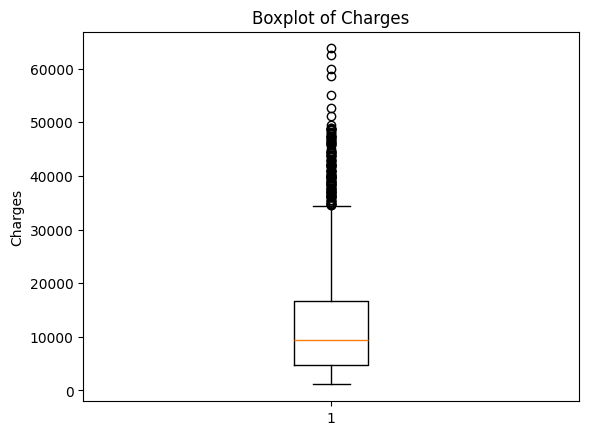

In [5]:
plt.boxplot(df['charges'])
plt.title('Boxplot of Charges')
plt.ylabel('Charges')
plt.show()

# EXPLORATORY DATA ANALYSIS (EDA)

## Distribusi Age

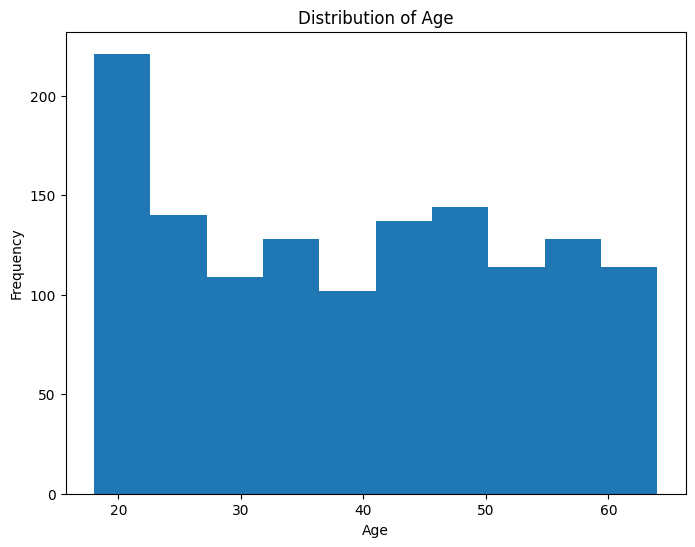



Range 18.0 - 22.6: 221 data
Range 22.6 - 27.2: 140 data
Range 27.2 - 31.8: 109 data
Range 31.8 - 36.4: 128 data
Range 36.4 - 41.0: 102 data
Range 41.0 - 45.6: 137 data
Range 45.6 - 50.2: 144 data
Range 50.2 - 54.8: 114 data
Range 54.8 - 59.4: 128 data
Range 59.4 - 64.0: 114 data


In [6]:
plt.figure(figsize=(8, 6))

n, bins, patches = plt.hist(df['age'], bins=10)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Age')
plt.show()

print("\n")
for i in range(len(n)):
    print(f"Range {bins[i]:.1f} - {bins[i+1]:.1f}: {int(n[i])} data")

## Distribusi BMI

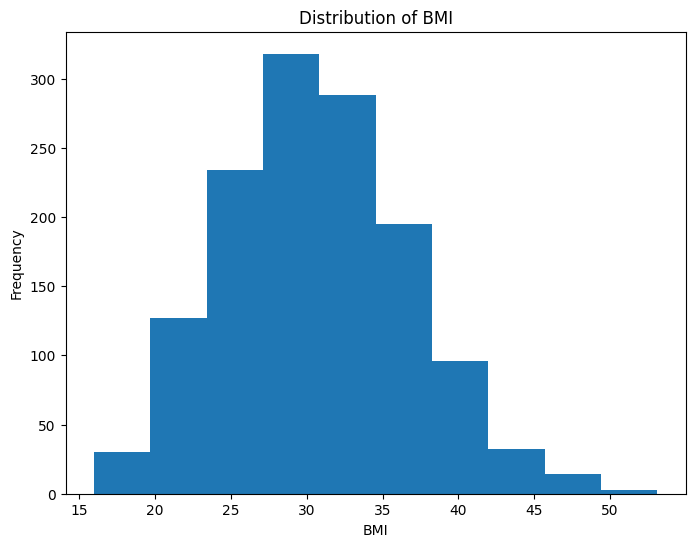



Range 16.0 - 19.7: 30 data
Range 19.7 - 23.4: 127 data
Range 23.4 - 27.1: 234 data
Range 27.1 - 30.8: 318 data
Range 30.8 - 34.5: 288 data
Range 34.5 - 38.3: 195 data
Range 38.3 - 42.0: 96 data
Range 42.0 - 45.7: 32 data
Range 45.7 - 49.4: 14 data
Range 49.4 - 53.1: 3 data


In [7]:
plt.figure(figsize=(8, 6))

n, bins, patches = plt.hist(df['bmi'], bins=10)
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.title('Distribution of BMI')
plt.show()

print("\n")
for i in range(len(n)):
    print(f"Range {bins[i]:.1f} - {bins[i+1]:.1f}: {int(n[i])} data")

## Distribusi Charges

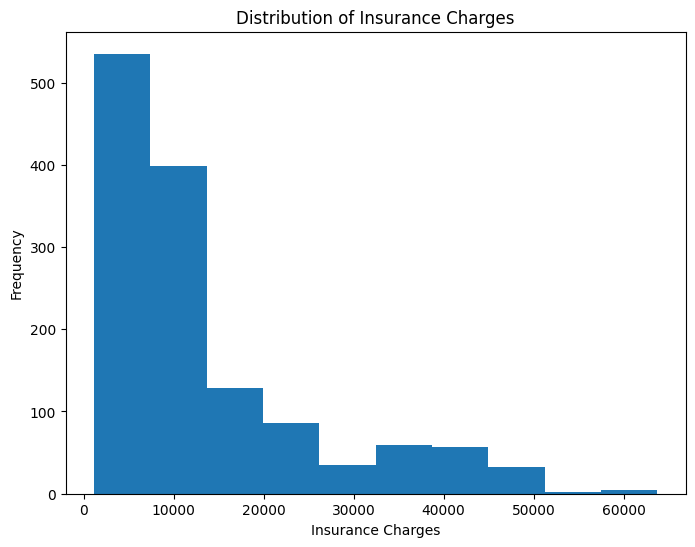



Range 1121.9 - 7386.7: 535 data
Range 7386.7 - 13651.6: 398 data
Range 13651.6 - 19916.4: 129 data
Range 19916.4 - 26181.3: 86 data
Range 26181.3 - 32446.2: 35 data
Range 32446.2 - 38711.0: 59 data
Range 38711.0 - 44975.9: 57 data
Range 44975.9 - 51240.7: 32 data
Range 51240.7 - 57505.6: 2 data
Range 57505.6 - 63770.4: 4 data


In [8]:
plt.figure(figsize=(8, 6))

n, bins, patches = plt.hist(df['charges'], bins=10)
plt.xlabel('Insurance Charges')
plt.ylabel('Frequency')
plt.title('Distribution of Insurance Charges')
plt.show()

print("\n")
for i in range(len(n)):
    print(f"Range {bins[i]:.1f} - {bins[i+1]:.1f}: {int(n[i])} data")

# CORRELATION ANALYSIS

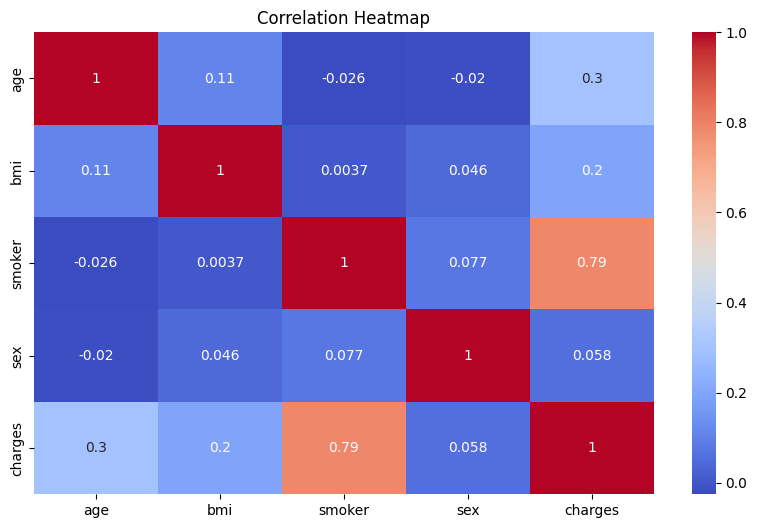

In [9]:
df_encoded = df.copy()
df_encoded['sex'] = df_encoded['sex'].map({'male': 1, 'female': 0})
df_encoded['smoker'] = df_encoded['smoker'].map({'yes': 1, 'no': 0})

corr_matrix = df_encoded[['age', 'bmi', 'smoker', 'sex', 'charges']].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# FEATURE ENGINEERING

## Age Category

In [10]:
def age_category(age):
  if age < 25:
    return "Pra Dewasa"
  elif age < 35:
    return "Dewasa Awal"
  elif age < 45:
    return "Dewasa Akhir"
  elif age < 55:
    return "Lansia Awal"
  else:
    return "Lansia Akhir"

df['age_category'] = df['age'].apply(age_category)
df['age_category'].value_counts()

,count
age_category,
Lansia Awal,287
Pra Dewasa,277
Dewasa Awal,271
Dewasa Akhir,260
Lansia Akhir,242


## BMI Category

In [11]:
def bmi_category(bmi):
  if bmi < 18.5:
    return "Underweight"
  elif bmi < 24.9:
    return "Normal"
  elif bmi < 29.9:
    return "Overweight"
  else:
    return "Obese"

df['bmi_category'] = df['bmi'].apply(bmi_category)
df['bmi_category'].value_counts()

,count
bmi_category,
Obese,718
Overweight,377
Normal,222
Underweight,20


## Risk Level

### Age Score

In [12]:
def age_score(age):
  if age < 35:
    return 1
  elif age < 50:
    return 2
  else:
    return 3

df['age_score'] = df['age'].apply(age_score)

### BMI Score

In [13]:
def bmi_score(bmi_category):
  if bmi_category == 'Normal':
    return 1
  elif bmi_category in ['Underweight', 'Overweight']:
    return 2
  else:
    return 3

df['bmi_score'] = df['bmi_category'].apply(bmi_score)

### Smoker Score

In [14]:
def smoker_score(smoker):
  if smoker == 'yes':
    return 4
  else:
    return 0

df['smoker_score'] = df['smoker'].apply(smoker_score)

### Total Risk Score

In [15]:
df['risk_score'] = df['age_score'] + df['bmi_score'] + df['smoker_score']
df['risk_score'].value_counts()

,count
risk_score,
4,358
5,246
6,216
3,176
8,96
2,88
9,61
7,54
10,42


risk_level
Medium Risk    820
Low Risk       264
High Risk      253
Name: count, dtype: int64


<Axes: xlabel='risk_level'>

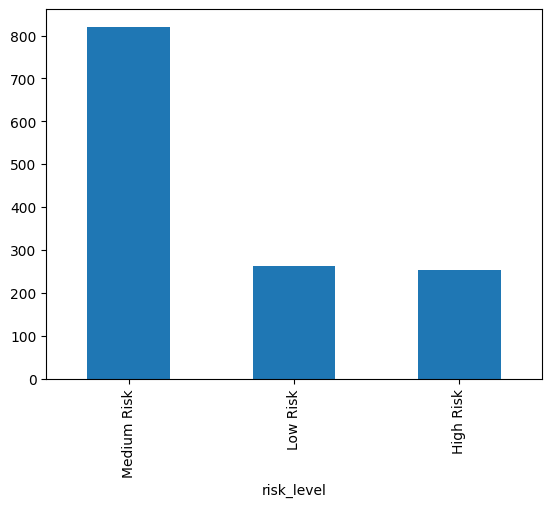

In [16]:
def risk_level(score):
  if score <= 3:
    return "Low Risk"
  elif score <= 6:
    return "Medium Risk"
  else:
    return "High Risk"

df['risk_level'] = df['risk_score'].apply(risk_level)

print(df['risk_level'].value_counts())
df['risk_level'].value_counts().plot(kind='bar')

# RISK & PRICING ANALYSIS

## Average Charges by Risk Level

risk_level
High Risk      33308.287556
Low Risk        5370.759932
Medium Risk     9645.497627
Name: charges, dtype: float64


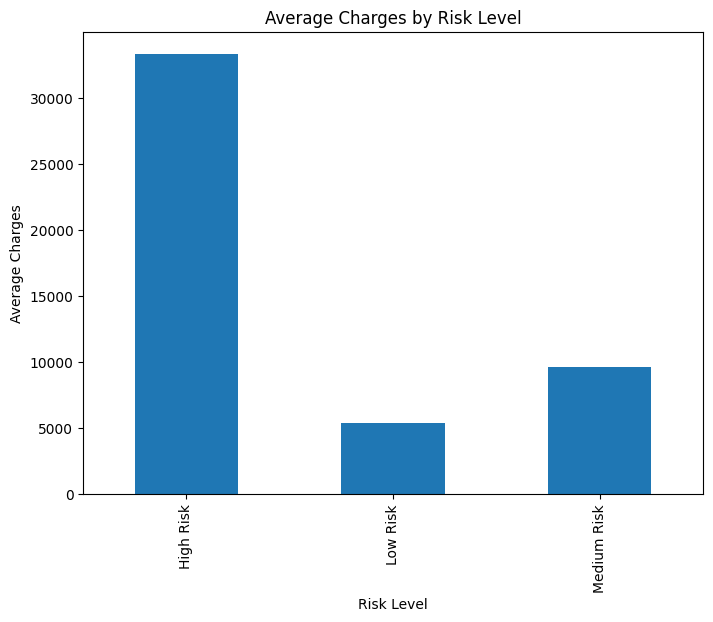

In [17]:
print(df.groupby('risk_level')['charges'].mean())
df.groupby('risk_level')['charges'].mean().plot(kind='bar', figsize=(8,6))

plt.title('Average Charges by Risk Level')
plt.xlabel('Risk Level')
plt.ylabel('Average Charges')
plt.show()

## Average Charges by Smoker Status

smoker
no      8440.660307
yes    32050.231832
Name: charges, dtype: float64


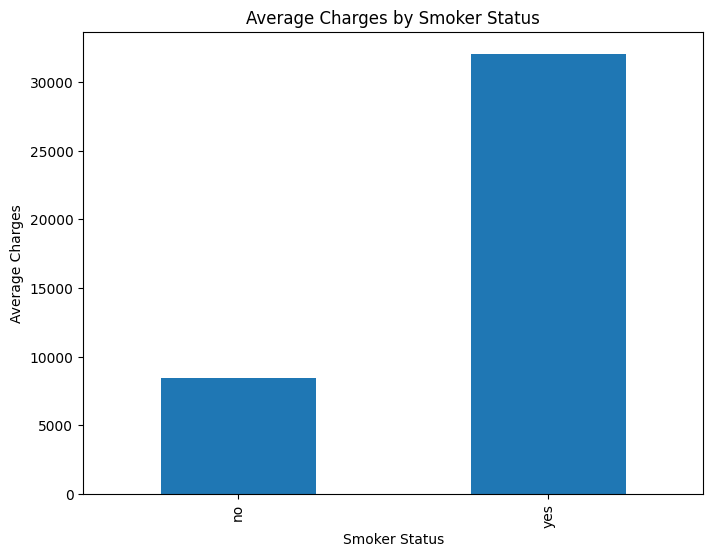

In [18]:
print(df.groupby('smoker')['charges'].mean())
df.groupby('smoker')['charges'].mean().plot(kind='bar', figsize=(8,6))

plt.title('Average Charges by Smoker Status')
plt.xlabel('Smoker Status')
plt.ylabel('Average Charges')
plt.show()

## Average Charges by BMI Category

bmi_category
Normal         10379.499732
Obese          15479.745716
Overweight     11030.331700
Underweight     8852.200585
Name: charges, dtype: float64


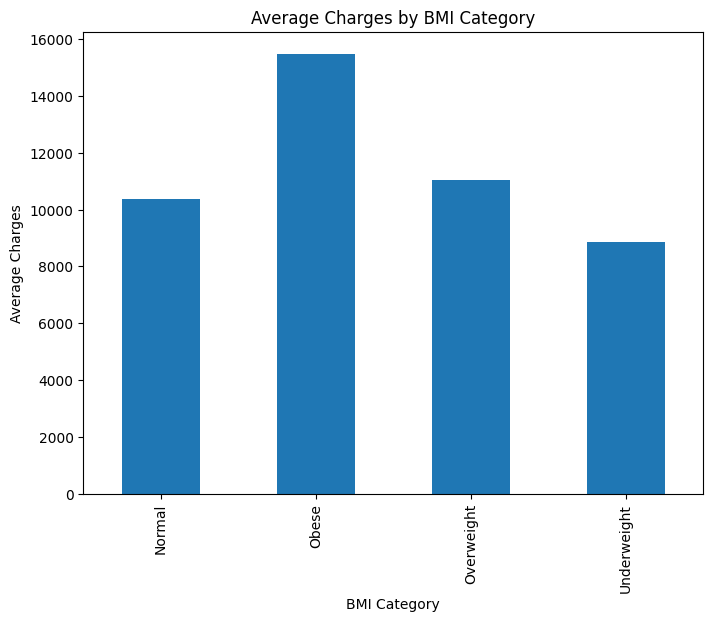

In [19]:
print(df.groupby('bmi_category')['charges'].mean())
df.groupby('bmi_category')['charges'].mean().plot(kind='bar', figsize=(8,6))

plt.title('Average Charges by BMI Category')
plt.xlabel('BMI Category')
plt.ylabel('Average Charges')
plt.show()

## Average Charges by Age Category

age_category
Dewasa Akhir    13134.168693
Dewasa Awal     10352.392526
Lansia Akhir    18513.276227
Lansia Awal     15853.927878
Pra Dewasa       9037.953231
Name: charges, dtype: float64


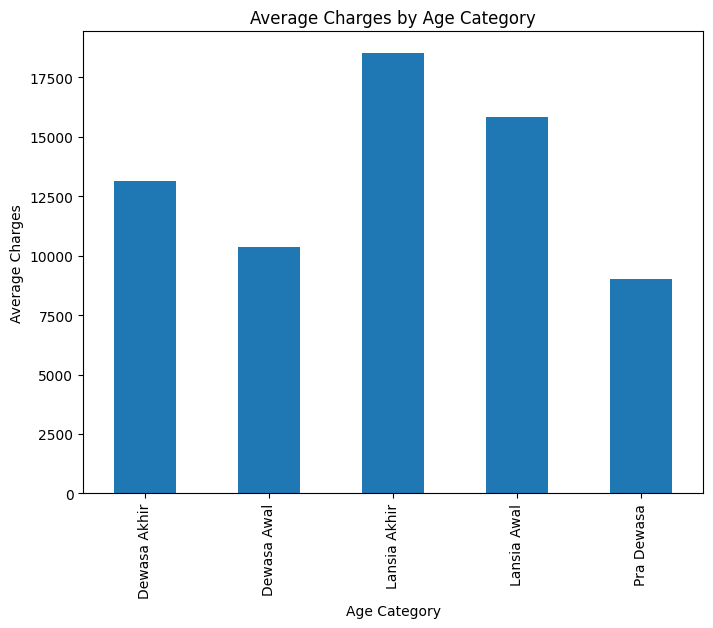

In [20]:
print(df.groupby('age_category')['charges'].mean())
df.groupby('age_category')['charges'].mean().plot(kind='bar', figsize=(8,6))

plt.title('Average Charges by Age Category')
plt.xlabel('Age Category')
plt.ylabel('Average Charges')
plt.show()

# Export

In [21]:
print(df.head())

df.to_excel('insurance_cleaned.xlsx', index=False)

   age     sex     bmi  children smoker     region      charges age_category  \
0   19  female  27.900         0    yes  southwest  16884.92400   Pra Dewasa   
1   18    male  33.770         1     no  southeast   1725.55230   Pra Dewasa   
2   28    male  33.000         3     no  southeast   4449.46200  Dewasa Awal   
3   33    male  22.705         0     no  northwest  21984.47061  Dewasa Awal   
4   32    male  28.880         0     no  northwest   3866.85520  Dewasa Awal   

  bmi_category  age_score  bmi_score  smoker_score  risk_score   risk_level  
0   Overweight          1          2             4           7    High Risk  
1        Obese          1          3             0           4  Medium Risk  
2        Obese          1          3             0           4  Medium Risk  
3       Normal          1          1             0           2     Low Risk  
4   Overweight          1          2             0           3     Low Risk  
